In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

In [2]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls "/content/drive/MyDrive"

'archive (1).zip'  'Colab Notebooks'   DATASET


In [5]:
import zipfile
zip_path="/content/drive/MyDrive/archive (1).zip"

with zipfile.ZipFile(zip_path,'r') as zip_ref:
  zip_ref.extractall('/content')

In [6]:
!find /content -type d | grep Covid19-dataset

/content/Covid19-dataset
/content/Covid19-dataset/test
/content/Covid19-dataset/test/Viral Pneumonia
/content/Covid19-dataset/test/Covid
/content/Covid19-dataset/test/Normal
/content/Covid19-dataset/train
/content/Covid19-dataset/train/Viral Pneumonia
/content/Covid19-dataset/train/Covid
/content/Covid19-dataset/train/Normal


In [7]:
df_train="/content/Covid19-dataset/train"
df_test="/content/Covid19-dataset/test"

In [8]:
image_classes=os.listdir(df_train)
image_classes

['Viral Pneumonia', 'Covid', 'Normal']

In [9]:
image_class=os.listdir(df_test)
image_class

['Viral Pneumonia', 'Covid', 'Normal']

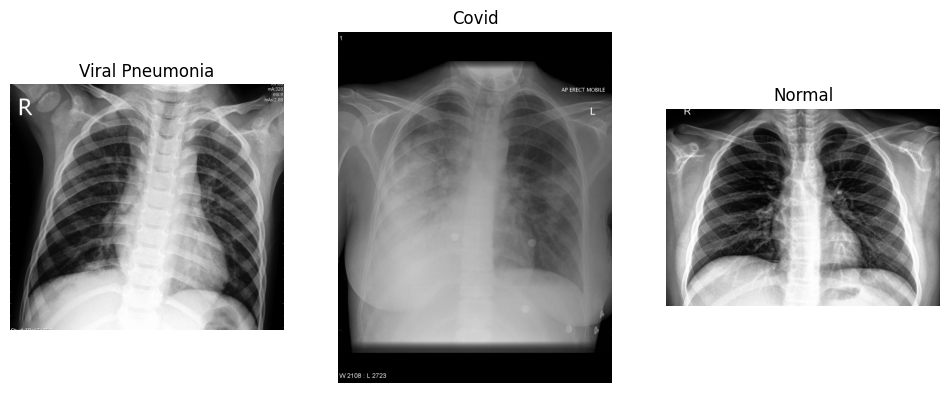

In [10]:
def plot_image(image_classes):
    plt.figure(figsize = (12,12))

    for i , category in enumerate(image_classes):
        image_path = df_train + '/' + category
        images_in_folder = os.listdir(image_path)

        first_image = images_in_folder[0]
        first_image_path = image_path + '/' + first_image

        img = image.load_img(first_image_path)
        img_array = image.img_to_array(img) / 255

        plt.subplot(1, 3, i+ 1)
        plt.imshow(img_array)
        plt.title(category)
        plt.axis('off')
    plt.show()


plot_image(image_classes)



In [11]:
image_class=os.listdir(df_test)
image_class

['Viral Pneumonia', 'Covid', 'Normal']

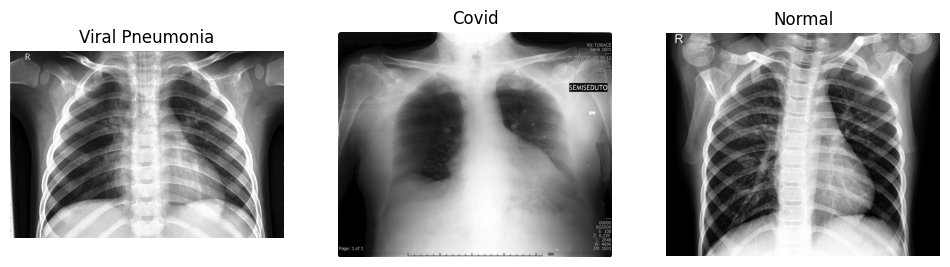

In [12]:
def img_test(image_class):
    plt.figure(figsize=(12,12))
    for i,category in enumerate(image_class):
        img_path=df_test+'/'+category
        img_path_folder=os.listdir(img_path)

        first_img=img_path_folder[0]
        first_img_path=img_path+'/'+first_img

        img=image.load_img(first_img_path)
        img_array=image.img_to_array(img)/255

        plt.subplot(3,3,i+1)
        plt.imshow(img_array)
        plt.title(category)
        plt.axis('off')

    plt.show()
img_test(image_class)

In [13]:
genertoy=ImageDataGenerator(rescale=1/255)


In [14]:
train_data=genertoy.flow_from_directory(df_train,target_size=(224,224),batch_size=32)

Found 251 images belonging to 3 classes.


In [15]:
test_data=genertoy.flow_from_directory(df_test,target_size=(224,224),batch_size=32)

Found 66 images belonging to 3 classes.


In [16]:
cnn_model=Sequential()

cnn_model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[224,224,3]))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(Flatten())

cnn_model.add(Dense(128,activation='relu'))
cnn_model.add(Dense(128,activation='relu'))


cnn_model.add(Dense(3,activation=softmax))



In [17]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,726,531 (98.14 MB)

 Trainable params: 25,726,531 (98.14 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
cnn_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [19]:
x=cnn_model.fit(train_data,epochs=10,validation_data=test_data)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.4661 - loss: 3.0427 - val_accuracy: 0.5152 - val_loss: 1.0147
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.8048 - loss: 0.7072 - val_accuracy: 0.6970 - val_loss: 0.6604
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.8964 - loss: 0.2881 - val_accuracy: 0.8636 - val_loss: 0.3825
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.9602 - loss: 0.1204 - val_accuracy: 0.8485 - val_loss: 0.3972
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.9522 - loss: 0.0912 - val_accuracy: 0.9545 - val_loss: 0.2038
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9960 - loss: 0.0255 - val_accuracy: 0.8939 - val_loss: 0.2774
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.9545 - val_loss: 0.2530
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.8939 - val_loss: 0.2723
Epoch 9/

In [20]:
cnn_model.evaluate(test_data)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - accuracy: 0.9545 - loss: 0.2546


[0.254610538482666, 0.9545454382896423]

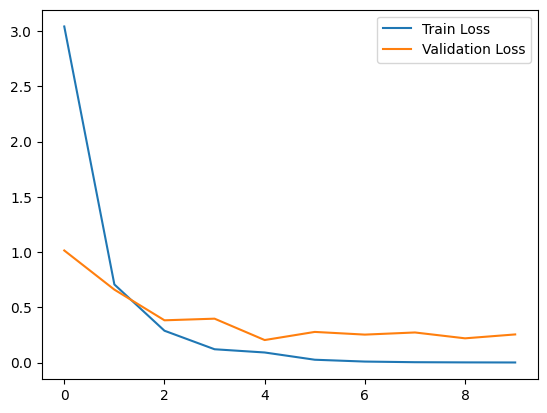

In [21]:
plt.plot(x.history['loss'], label = 'Train Loss')
plt.plot(x.history['val_loss'], label = 'Validation Loss')
plt.legend()
plt.show()

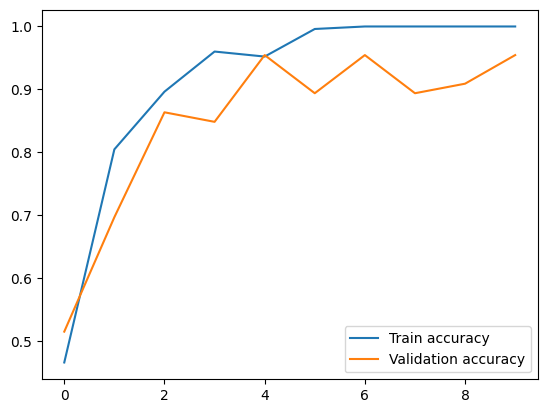

In [22]:
plt.plot(x.history['accuracy'], label = 'Train accuracy')
plt.plot(x.history['val_accuracy'], label = 'Validation accuracy')
plt.legend()
plt.show()

In [23]:
cnn_model.evaluate(train_data)

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 1.0000 - loss: 5.9973e-04


[0.0005997337866574526, 1.0]

In [24]:
cnn_model.save('covid_19_model.h5')

In [25]:
class_map=dict([value,key] for key,value in  test_data.class_indices.items())
class_map

{0: 'Covid', 1: 'Normal', 2: 'Viral Pneumonia'}

In [26]:
def predict_class(test_image, actual_label):



    testing_img = image.load_img(test_image, target_size = (224, 224))

    test_img_array = image.img_to_array(testing_img) / 255


    test_img_input = test_img_array.reshape(1, test_img_array.shape[0],
                                               test_img_array.shape[1], test_img_array.shape[2])



    predicted_class = np.argmax(cnn_model.predict(test_img_input))
    predicted_label = class_map[predicted_class]

    plt.figure(figsize = (4,4))
    plt.imshow(test_img_array)
    plt.title('Actual Label : {}, Prediected Label : {}'.format(actual_label, predicted_label))
    plt.grid()
    plt.axis('off')

In [27]:
test_image="/content/Covid19-dataset/test/Normal/0120.jpeg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


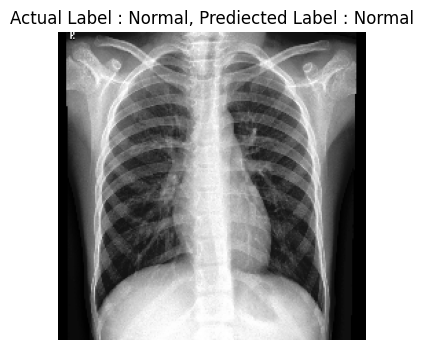

In [28]:
from tensorflow.keras.preprocessing import image
predict_class(test_image, actual_label = 'Normal')

## DenseNet121 Model Implementation

In [29]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model

# Load pre-trained DenseNet121 model without the top (classification) layer
densenet_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the base model so they are not trained
for layer in densenet_base.layers:
    layer.trainable = False

# Build the new model on top of DenseNet121
x = densenet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(3, activation='softmax')(x) # 3 classes for Covid, Normal, Viral Pneumonia

densenet_model = Model(inputs=densenet_base.input, outputs=predictions)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
densenet_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,169,091 (27.35 MB)

 Trainable params: 131,587 (514.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [31]:
densenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [32]:
y_densenet = densenet_model.fit(train_data, epochs=10, validation_data=test_data)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - accuracy: 0.6016 - loss: 0.8642 - val_accuracy: 0.6818 - val_loss: 0.5929
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 57s 7s/step - accuracy: 0.8805 - loss: 0.3479 - val_accuracy: 0.8636 - val_loss: 0.4186
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 69s 9s/step - accuracy: 0.9163 - loss: 0.2584 - val_accuracy: 0.8636 - val_loss: 0.3677
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 58s 7s/step - accuracy: 0.9402 - loss: 0.1988 - val_accuracy: 0.8636 - val_loss: 0.3327
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 66s 8s/step - accuracy: 0.9522 - loss: 0.1674 - val_accuracy: 0.8636 - val_loss: 0.3148
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 59s 7s/step - accuracy: 0.9602 - loss: 0.1242 - val_accuracy: 0.8788 - val_loss: 0.2459
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 59s 8s/step - accuracy: 0.9801 - loss: 0.0946 - val_accuracy: 0.8788 - val_loss: 0.2203
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 67s 9s/step - accuracy: 0.9841 - loss: 0.0819 - val_accuracy: 0.9091 - val_loss: 0.2150
Epoch 9/

In [33]:
densenet_model.evaluate(test_data)

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.9242 - loss: 0.2083


[0.20830777287483215, 0.9242424368858337]

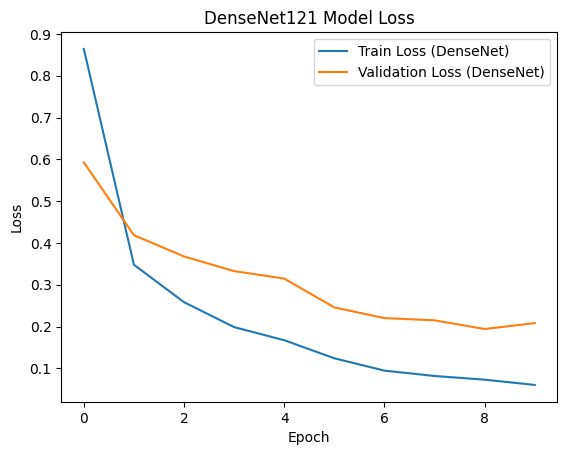

In [34]:
plt.plot(y_densenet.history['loss'], label = 'Train Loss (DenseNet)')
plt.plot(y_densenet.history['val_loss'], label = 'Validation Loss (DenseNet)')
plt.legend()
plt.title('DenseNet121 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

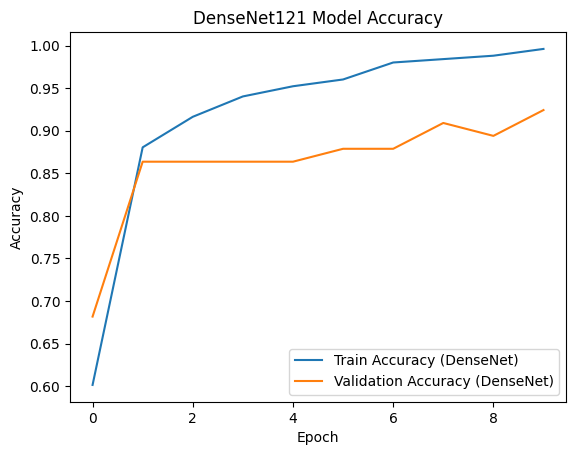

In [35]:
plt.plot(y_densenet.history['accuracy'], label = 'Train Accuracy (DenseNet)')
plt.plot(y_densenet.history['val_accuracy'], label = 'Validation Accuracy (DenseNet)')
plt.legend()
plt.title('DenseNet121 Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [36]:
%%writefile covid_19app.py

import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from PIL import Image

model_path = r"C:\Users\ALMot7da\Documents\covid_19_model.h5"
model = load_model(model_path)

class_map = {0: "COVID", 1: "Normal", 2: "Pneumonia"}

st.title("COVID-19 Detection from Chest X-ray")

uploaded_file = st.file_uploader("Upload Chest X-ray Image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    try:
        img = Image.open(uploaded_file).convert("RGB")
    except Exception as e:
        st.error("Error loading image. Please upload a valid image file.")
        st.stop()

    st.image(img, caption="Uploaded Image", use_container_width=True)

    # Resize image to model input size
    img = img.resize((224, 200))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array)[0]  # prediction shape (3,)
    predicted_class = np.argmax(prediction)
    predicted_label = class_map[predicted_class]

    # Display main prediction
    st.success(f"**Prediction:** {predicted_label}")

    # Display probabilities for all classes
    st.subheader("Prediction Confidence")
    for i, label in class_map.items():
        st.write(f"{label}: {prediction[i]*100:.2f}%")

else:
    st.info("Please upload an image file to get prediction.")



Writing covid_19app.py
